# Fase 2: Construcción del Panel y EDA

Análisis exploratorio sobre `panel_clean` (tabla país×año limpia, construida por `src/panel_build.py` a partir de `raw_observations` + `country_reference`). Estadísticas descriptivas, patrón de datos faltantes (riesgo MNAR) y matriz de correlación/VIF a nivel global, regional y por tipología de país (LDC/LLDC/SIDS).

In [1]:
import sys
from pathlib import Path

# Notebook lives in notebook/, but `src/` and `data/panel.db` are relative to
# the project root -- add the project root to sys.path and chdir there so
# this notebook runs correctly regardless of launch method (nbconvert,
# Jupyter Lab, VS Code) or invocation cwd.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant

from src import db

INDICATOR_COLS = ["6.4.2", "6.4.1", "8.1.1", "8.2.1", "2.3.1"]
TYPOLOGY_FLAGS = ["is_ldc", "is_lldc", "is_sids"]

engine = db.get_engine(str(PROJECT_ROOT / "data" / "panel.db"))


In [2]:
panel_clean = pd.read_sql("SELECT * FROM panel_clean", engine)
panel_exclusions = pd.read_sql("SELECT * FROM panel_exclusions", engine)

print("panel_clean shape:", panel_clean.shape)
print("panel_clean columns:", list(panel_clean.columns))
print("panel_exclusions shape:", panel_exclusions.shape)


panel_clean shape: (4923, 12)
panel_clean columns: ['country_code', 'year', 'region', 'subregion', 'is_ldc', 'is_lldc', 'is_sids', '2.3.1', '6.4.1', '6.4.2', '8.1.1', '8.2.1']
panel_exclusions shape: (529, 7)


## Estadísticas descriptivas globales

In [3]:
descriptive_stats = panel_clean[INDICATOR_COLS].describe()
descriptive_stats


,6.4.2,6.4.1,8.1.1,8.2.1,2.3.1
count,4041.000000,3530.000000,4790.000000,4300.000000,173.000000
mean,56.589706,41.618674,2.172610,1.667644,50.352197
std,236.173950,101.072227,6.226705,5.374953,37.589166
min,0.010000,0.170000,-55.200000,-53.890000,1.900000
25%,3.580000,4.882500,0.000000,-0.432500,10.500000
50%,10.460000,13.165000,2.200000,1.605000,50.800000
75%,34.960000,40.597500,4.600000,3.870000,77.400000
max,3850.500000,1394.860000,95.800000,92.450000,147.100000


## Patrón de datos faltantes (riesgo MNAR)

In [4]:
missing_by_indicator = (panel_clean[INDICATOR_COLS].isna().mean() * 100).round(1)
missing_by_indicator.name = "pct_missing"
missing_by_indicator


6.4.2    17.9
6.4.1    28.3
8.1.1     2.7
8.2.1    12.7
2.3.1    96.5
Name: pct_missing, dtype: float64

In [5]:
missing_by_region = (
    panel_clean.groupby("region")[INDICATOR_COLS]
    .apply(lambda g: g.isna().mean() * 100)
    .round(1)
)
missing_by_region_overall = missing_by_region.mean(axis=1).sort_values(ascending=False)
missing_by_region_overall.name = "pct_missing_avg_across_indicators"
missing_by_region_overall


region
Oceania                             61.66
Europe and Northern America         46.52
Latin America and the Caribbean     39.94
Eastern and South-Eastern Asia      28.50
Europe                              27.20
Central and Southern Asia           24.04
Northern Africa and Western Asia    23.52
Sub-Saharan Africa                  23.36
Name: pct_missing_avg_across_indicators, dtype: float64

In [6]:
missing_by_typology = pd.DataFrame({
    flag: panel_clean.groupby(flag)[INDICATOR_COLS].apply(lambda g: g.isna().mean().mean() * 100).round(1)
    for flag in TYPOLOGY_FLAGS
})
missing_by_typology.index.name = "flag_value"
missing_by_typology


,is_ldc,is_lldc,is_sids
flag_value,,,
0,33.1,33.3,26.3
1,25.9,21.8,49.9


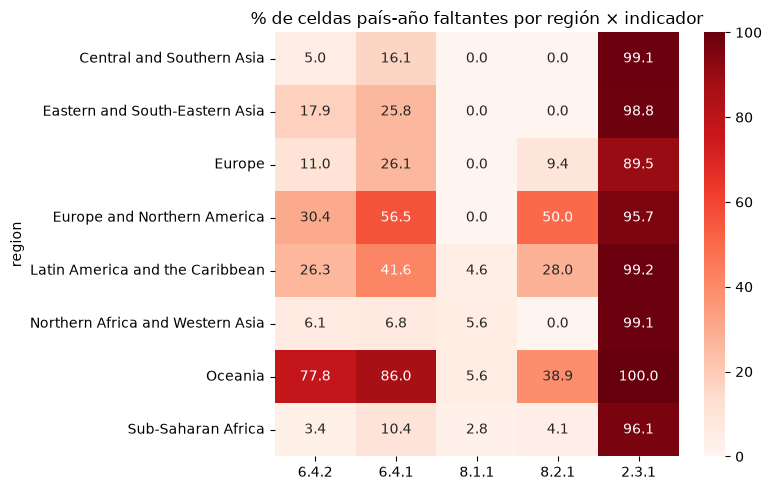

In [7]:
# Single static missingness figure (not a reusable/interactive report tool --
# EXTRA-01 stays deferred; this is a one-off EDA figure for PANEL-03).
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(missing_by_region, annot=True, fmt=".1f", cmap="Reds", ax=ax)
ax.set_title("% de celdas país-año faltantes por región × indicador")
plt.tight_layout()
plt.show()


### Discusión: patrón de datos faltantes y riesgo MNAR

El patrón de valores faltantes observado **no es plausible como MCAR** (missing completely at random): la proporción de celdas faltantes varía fuertemente por indicador (desde 2.7% en 8.1.1 hasta 96.5% en 2.3.1 -- producción agrícola por unidad de trabajo, que solo 50 de más de 200 países reportan) y también varía sistemáticamente por región y por tipología de país. Esto descarta que la ausencia de datos sea independiente de las características del país.

**Evidencia concreta de sesgo por tipología (riesgo MNAR):** los países clasificados como SIDS (Small Island Developing States) muestran una tasa de valores faltantes del **49.9%** (promedio across los 5 indicadores), casi el doble que los países no-SIDS (**26.3%**) -- un patrón consistente con la hipótesis de que la capacidad estadística limitada de estados insulares pequeños afecta simultáneamente su reporte de indicadores hídricos y económicos. La región de Oceanía (**61.6%** de valores faltantes en promedio) es, coherentemente, la región con mayor tasa de ausencia -- Oceanía concentra buena parte de los países SIDS de la muestra.

**Matiz honesto:** el patrón no es uniforme en los tres ejes de tipología -- los países LDC (25.9% de valores faltantes) y LLDC (21.8%) muestran de hecho *menor* tasa de valores faltantes que sus contrapartes no-LDC/no-LLDC (33.1% y 33.3% respectivamente) en este promedio agregado. Esto no contradice el riesgo MNAR global -- refleja que la relación entre tipología de vulnerabilidad y capacidad estadística no es lineal ni uniforme entre las tres clasificaciones (LDC/LLDC agrupa un conjunto de países más numeroso y heterogéneo que SIDS, y varios países LDC de África Subsahariana con buena cobertura en los indicadores hídricos compensan el promedio). El sesgo más claro y consistente en estos datos es el de **SIDS** y el indicador **2.3.1** específicamente.

**Ilustración concreta vía `panel_exclusions`:** de las combinaciones (país, indicador) documentadas como excluidas por no alcanzar el 70% de cobertura de años, la gran mayoría corresponde al indicador 2.3.1 (más de 150 de los ~215 países), confirmando que este indicador -- más que el proceso de panel en sí -- concentra el riesgo de sesgo hacia países con mejor reporting estadístico agrícola.

**Implicación para el Modelo 1 (Fase 3):** cualquier análisis de complete-case (listwise deletion) sobre estas variables sobrerrepresentaría sistemáticamente a países con mejor capacidad estadística, un sesgo que debe reconocerse explícitamente al interpretar los coeficientes del modelo de panel, no solo al reportar el tamaño muestral.